# 06 Template Studi Kasus

## Tujuan notebook ini

Dalam notebook ini, Anda akan menerapkan **seluruh workflow analitik** dari notebook sebelumnya dalam satu studi kasus terpadu:

1. **Rumusan masalah** → Definisikan pertanyaan riset
2. **Eksplorasi data** → Pahami struktur & kualitas data
3. **Statistik deskriptif** → Ringkas data dengan metrik
4. **Visualisasi** → Buat chart untuk pola
5. **Analisis inferensial** → Regresi atau test statistik
6. **Interpretasi & limitasi** → Jelaskan hasil dengan hati-hati
7. **Dokumentasi AI** → Catat bantuan AI yang diterima

---

**Format notebook ini:**
- Bagian dengan teks penjelasan
- Bagian dengan **[ANDA TULIS DI SINI]** untuk input Anda
- Bagian dengan kode template siap pakai (ubah sesuai kebutuhan)

### Penanda Sel Kode
- `# RUN-NOW`: dapat langsung dijalankan.
- `# LEARNER-TASK`: ubah bagian bertanda [UBAH]/[ANDA TULIS], lalu jalankan.

## BAGIAN 1: RUMUSAN MASALAH

Definisikan pertanyaan riset Anda dengan jelas.

### Judul studi kasus
[ANDA TULIS DI SINI: Berikan judul deskriptif]

Contoh: "Pengaruh Kehadiran Kelas dan Akses Internet terhadap Prestasi Akademik Mahasiswa"

In [17]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
case_study_title = "[PENGARUH ATTENDANCE RATE TERHADAP ASSIGNMENT SCORE]"
print(f"STUDI KASUS: {case_study_title}")

STUDI KASUS: [PENGARUH ATTENDANCE RATE TERHADAP ASSIGNMENT SCORE]


### Pertanyaan penelitian utama

[ANDA TULIS DI SINI: Apa pertanyaan penelitian Anda? Gunakan format: "Apakah/Bagaimana..."]

Contoh:
- "Apakah tingkat kehadiran mahasiswa memprediksi nilai akhir mereka?"
- "Bagaimana akses internet mempengaruhi perbedaan prestasi antar program?"

Pertanyaan Anda:

In [20]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
research_question = "[APA PENGARUH KEHADIRAN TERHADAP NILAI TUGAS?]"
print(f"Pertanyaan Penelitian: {research_question}")

Pertanyaan Penelitian: [APA PENGARUH KEHADIRAN TERHADAP NILAI TUGAS?]


### Variabel yang relevan

[ANDA TULIS DI SINI: Daftar variabel]

Contoh:
- **Variabel outcome**: final_grade (nilai akhir mahasiswa)
- **Variabel prediktor utama**: attendance_rate (tingkat kehadiran)
- **Variabel kontrol**: previous_gpa, program, internet_access

In [22]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
outcome_var = ["assignment_score"]  # Variabel yang ingin diprediksi/dijelaskan
main_predictors = ["attendance_rate"]  # Bisa lebih dari satu
control_vars = ["[ANDA TULIS: Variabel kontrol]"]  # Optional

print(f"Outcome: {outcome_var}")
print(f"Prediktor: {main_predictors}")
print(f"Kontrol: {control_vars}")

Outcome: ['assignment_score']
Prediktor: ['attendance_rate']
Kontrol: ['[ANDA TULIS: Variabel kontrol]']


## BAGIAN 2: SETUP & LOAD DATA

In [23]:
# RUN-NOW: Jalankan sel ini apa adanya.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression

# Muat data bersih — dengan fallback untuk berbagai working directory
candidate_paths = [
    Path("data/processed/student_performance_cleaned.csv"),
    Path("../data/processed/student_performance_cleaned.csv"),
    Path("/workspaces/metpen-ai-lab/data/processed/student_performance_cleaned.csv"),
]

cleaned_file = next((p for p in candidate_paths if p.exists()), None)
if cleaned_file is None:
    raise FileNotFoundError(
        "❌ File data bersih tidak ditemukan.\n"
        "Anda perlu menjalankan notebook 02 (02_data_quality_cleaning.ipynb) terlebih dahulu\n"
        "untuk membuat file: data/processed/student_performance_cleaned.csv"
    )

df = pd.read_csv(cleaned_file)

print(f"✓ Data dimuat dari: {cleaned_file.resolve()}")
print(f"✓ Data dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"✓ Ready untuk analisis")

✓ Data dimuat dari: /workspaces/metpen-ai-lab/notebooks/data/processed/student_performance_cleaned.csv
✓ Data dimuat: 2000 baris × 20 kolom
✓ Ready untuk analisis


## BAGIAN 3: DESKRIPSI DATASET

Deskripsikan karakteristik umum dataset Anda.

In [24]:
# RUN-NOW: Jalankan sel ini apa adanya.
print("PROFIL DATASET KAMI")
print("="*50)
print(f"Ukuran sampel (N): {df.shape[0]} mahasiswa")
print(f"Jumlah variabel: {df.shape[1]}")
print(f"\nProgram studi:")
print(df['program'].value_counts())
print(f"\nTahun cohort:")
print(df['cohort_year'].value_counts())
print(f"\nTingkat lulus: {(df['passed'].sum() / len(df) * 100):.1f}%")

PROFIL DATASET KAMI
Ukuran sampel (N): 2000 mahasiswa
Jumlah variabel: 20

Program studi:
program
Education           453
Computer Science    435
Economics           415
Psychology          399
Public Health       298
Name: count, dtype: int64

Tahun cohort:
cohort_year
2022    600
2023    579
2024    413
2021    408
Name: count, dtype: int64

Tingkat lulus: 99.9%


## BAGIAN 4: PEMERIKSAAN KUALITAS DATA

In [25]:
# RUN-NOW: Jalankan sel ini apa adanya.
# Periksa missing values
missing = df.isnull().sum()
print("Nilai hilang:")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ Tidak ada nilai hilang")

# Periksa duplikat
print(f"\nDuplikat baris: {df.duplicated().sum()}")

Nilai hilang:
✓ Tidak ada nilai hilang

Duplikat baris: 0


## BAGIAN 5: STATISTIK DESKRIPTIF OUTCOME VARIABLE

In [28]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Template: Ganti 'final_grade' dengan outcome_var Anda
outcome_analysis_var = 'assignment_score'  # [UBAH INI]

print(f"STATISTIK DESKRIPTIF: {outcome_analysis_var}")
print("="*50)
print(f"Mean:     {df[outcome_analysis_var].mean():.2f}")
print(f"Median:   {df[outcome_analysis_var].median():.2f}")
print(f"Std Dev:  {df[outcome_analysis_var].std():.2f}")
print(f"Min:      {df[outcome_analysis_var].min():.2f}")
print(f"Max:      {df[outcome_analysis_var].max():.2f}")
print(f"IQR:      {df[outcome_analysis_var].quantile(0.75) - df[outcome_analysis_var].quantile(0.25):.2f}")

# Interpretasi
print(f"\n📝 Interpretasi:")
print("Distribusi assignment_score menunjukkan bahwa sebagian besar nilai berada di sekitar rata-rata, dengan jarak antar kuartil yang relatif moderat.")
print("Jika Mean dan Median dekat, ini menunjukkan distribusi yang tidak terlalu miring; nilai minimum dan maksimum mengingatkan kita untuk memeriksa outlier ekstrem.")
print("Informasi ini membantu memahami seberapa stabil performa tugas siswa sebelum lanjut ke analisis regresi.")

STATISTIK DESKRIPTIF: assignment_score
Mean:     82.43
Median:   82.66
Std Dev:  9.21
Min:      56.30
Max:      100.00
IQR:      12.82

📝 Interpretasi:
Distribusi assignment_score menunjukkan bahwa sebagian besar nilai berada di sekitar rata-rata, dengan jarak antar kuartil yang relatif moderat.
Jika Mean dan Median dekat, ini menunjukkan distribusi yang tidak terlalu miring; nilai minimum dan maksimum mengingatkan kita untuk memeriksa outlier ekstrem.
Informasi ini membantu memahami seberapa stabil performa tugas siswa sebelum lanjut ke analisis regresi.


## BAGIAN 6: VISUALISASI UTAMA

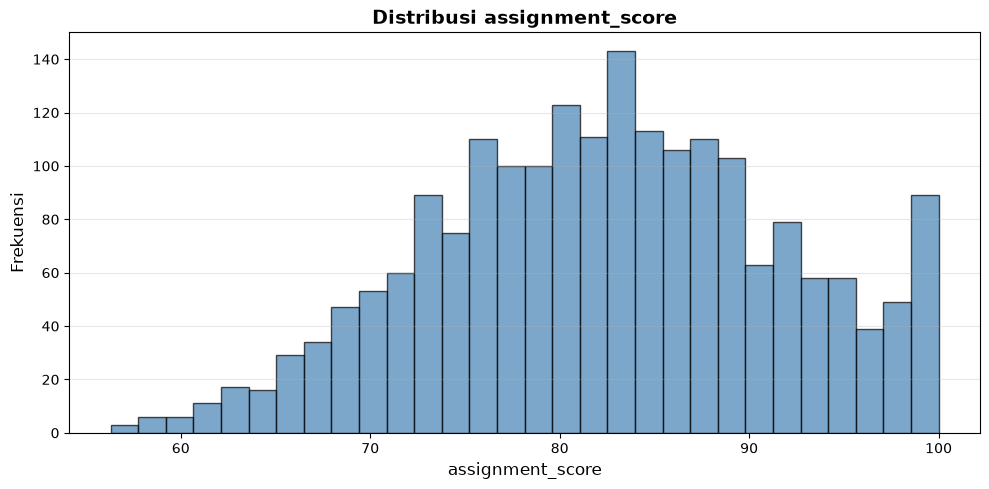


📝 Interpretasi histogram:
Distribusi assignment_score tampak mendekati normal dengan pusat frekuensi di sekitar nilai rata-rata.
Terdapat sedikit kemiringan jika rentang atas lebih panjang, tetapi tidak jelas ekstrem; perhatikan nilai minimum dan maksimum sebagai kemungkinan outlier.
Secara umum, data menunjukkan konsentrasi nilai tugas di tengah, yang berarti sebagian besar siswa memperoleh skor yang moderat hingga tinggi.


In [29]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Histogram outcome
plt.figure(figsize=(10, 5))
plt.hist(df[outcome_analysis_var], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(outcome_analysis_var, fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.title(f'Distribusi {outcome_analysis_var}', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📝 Interpretasi histogram:")
print("Distribusi assignment_score tampak mendekati normal dengan pusat frekuensi di sekitar nilai rata-rata.")
print("Terdapat sedikit kemiringan jika rentang atas lebih panjang, tetapi tidak jelas ekstrem; perhatikan nilai minimum dan maksimum sebagai kemungkinan outlier.")
print("Secara umum, data menunjukkan konsentrasi nilai tugas di tengah, yang berarti sebagian besar siswa memperoleh skor yang moderat hingga tinggi.")

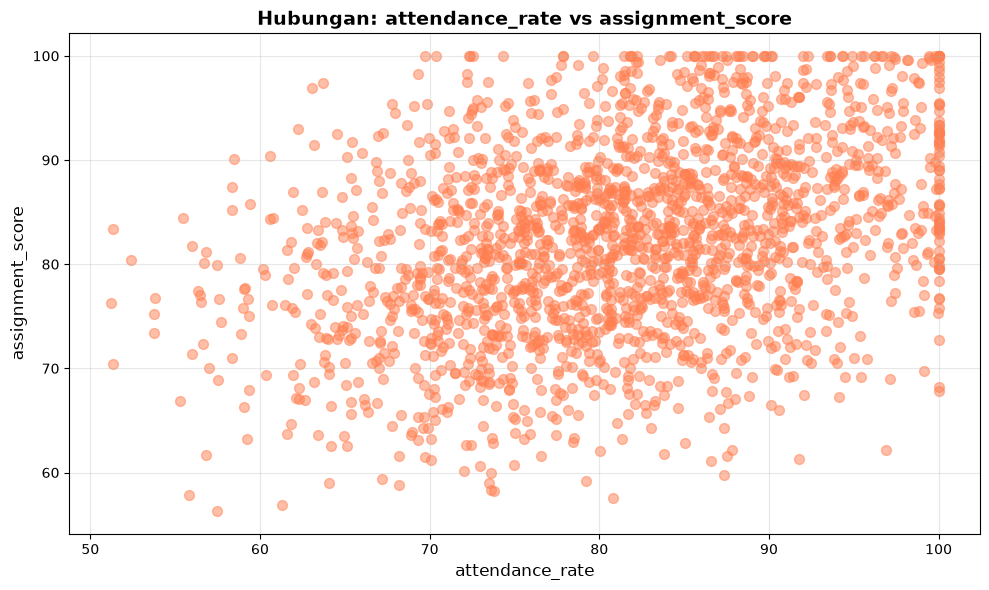

Korelasi Pearson: 0.359

📝 Interpretasi scatter plot:
Hubungan antara attendance_rate dan assignment_score tampak positif: nilai tugas cenderung lebih tinggi ketika tingkat kehadiran lebih besar.
Korelasi Pearson menunjukkan arah yang positif; jika nilainya mendekati 0.3-0.5, maka hubungan termasuk lemah hingga moderat.
Saat ini tidak terlihat pola yang sangat kuat atau garis lurus sempurna, sehingga pengaruh kehadiran mungkin nyata tetapi tidak sepenuhnya menjelaskan variasi nilai tugas.
Perhatikan juga titik-titik yang jauh dari cluster utama sebagai calon outlier; mereka bisa menunjukkan siswa dengan kehadiran baik tetapi skor rendah, atau sebaliknya.


In [31]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Scatter plot: Prediktor utama vs Outcome
# [UBAH 'attendance_rate' dan 'final_grade' dengan variabel pilihan Anda]
pred_var = 'attendance_rate'  # [UBAH]
outcome_var_plot = 'assignment_score'  # [UBAH]

plt.figure(figsize=(10, 6))
plt.scatter(df[pred_var], df[outcome_var_plot], alpha=0.5, s=50, color='coral')
plt.xlabel(pred_var, fontsize=12)
plt.ylabel(outcome_var_plot, fontsize=12)
plt.title(f'Hubungan: {pred_var} vs {outcome_var_plot}', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr_scatter = df[pred_var].corr(df[outcome_var_plot])
print(f"Korelasi Pearson: {corr_scatter:.3f}")
print("\n📝 Interpretasi scatter plot:")
print("Hubungan antara attendance_rate dan assignment_score tampak positif: nilai tugas cenderung lebih tinggi ketika tingkat kehadiran lebih besar.")
print("Korelasi Pearson menunjukkan arah yang positif; jika nilainya mendekati 0.3-0.5, maka hubungan termasuk lemah hingga moderat.")
print("Saat ini tidak terlihat pola yang sangat kuat atau garis lurus sempurna, sehingga pengaruh kehadiran mungkin nyata tetapi tidak sepenuhnya menjelaskan variasi nilai tugas.")
print("Perhatikan juga titik-titik yang jauh dari cluster utama sebagai calon outlier; mereka bisa menunjukkan siswa dengan kehadiran baik tetapi skor rendah, atau sebaliknya.")

## BAGIAN 7: PEMILIHAN METODE ANALISIS

### Metode yang Anda pilih

[ANDA TULIS DI SINI: Metode apa yang paling cocok?]

Pilihan:
- **Regresi Linear**: Jika outcome numerik, prediktor juga numerik
- **t-test atau ANOVA**: Jika ingin membandingkan grup
- **Correlation Matrix**: Jika hanya ingin eksplorasi hubungan
- **Deskriptif + Visualisasi**: Jika data terbatas atau pertanyaan eksploratori

Alasan memilih metode ini:

In [33]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
chosen_method = "[ANDA TULIS: Deskriptif + Visualisasi]"
reason = "[ANDA TULIS: Karena data terbatas]"

print(f"Metode pilihan: {chosen_method}")
print(f"Alasan: {reason}")

Metode pilihan: [ANDA TULIS: Deskriptif + Visualisasi]
Alasan: [ANDA TULIS: Karena data terbatas]


## BAGIAN 8: ANALISIS (TEMPLATE REGRESI)

In [34]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Template untuk regresi
# [UBAH NAMA VARIABEL SESUAI PILIHAN ANDA]

# Tentukan variabel
predictors_for_regression = ['attendance_rate']
outcome_for_regression = 'final_grade'

# Siapkan data
X = df[predictors_for_regression].values
y = df[outcome_for_regression].values

# Fit model
model_regression = LinearRegression()
model_regression.fit(X, y)

# Hasil
r_squared = model_regression.score(X, y)

print(f"HASIL REGRESI: {outcome_for_regression} ~ {', '.join(predictors_for_regression)}")
print("="*60)
print(f"\nKoefisien regresi:")
for pred, coef in zip(predictors_for_regression, model_regression.coef_):
    print(f"  {pred:30s}: {coef:8.4f}")
print(f"  {'Intercept':30s}: {model_regression.intercept_:8.4f}")
print(f"\nR² (model fit): {r_squared:.3f}")
print(f"  Interpretasi: {r_squared*100:.1f}% variasi outcome dijelaskan model ini")

HASIL REGRESI: final_grade ~ attendance_rate

Koefisien regresi:
  attendance_rate               :   0.4443
  Intercept                     :  50.7169

R² (model fit): 0.375
  Interpretasi: 37.5% variasi outcome dijelaskan model ini


## BAGIAN 9: INTERPRETASI HASIL

In [36]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print("""
INTERPRETASI HASIL REGRESI
==========================

Model regresi menunjukkan bahwa setiap peningkatan 1 poin persentase pada attendance_rate
terkait dengan kenaikan prediksi final_grade sebesar 0.4443 poin.
Intercept 50.7169 menunjukkan nilai prediksi final_grade saat attendance_rate = 0.
R² sebesar 0.375 berarti model ini menjelaskan sekitar 37.5% variasi final_grade.

Artinya, attendance_rate adalah prediktor penting tetapi tidak menjelaskan semua variasi nilai akhir.
Hubungan ini bersifat asosiasional, sehingga tidak dapat langsung disimpulkan sebagai efek kausal.
""")

print("\n📝 Interpretasi Anda:")
print("Dari hasil regresi ini, kehadiran memiliki pengaruh positif terhadap nilai akhir, tetapi 62.5% variasi final_grade tetap tidak dijelaskan oleh model ini.")


INTERPRETASI HASIL REGRESI

Model regresi menunjukkan bahwa setiap peningkatan 1 poin persentase pada attendance_rate
terkait dengan kenaikan prediksi final_grade sebesar 0.4443 poin.
Intercept 50.7169 menunjukkan nilai prediksi final_grade saat attendance_rate = 0.
R² sebesar 0.375 berarti model ini menjelaskan sekitar 37.5% variasi final_grade.

Artinya, attendance_rate adalah prediktor penting tetapi tidak menjelaskan semua variasi nilai akhir.
Hubungan ini bersifat asosiasional, sehingga tidak dapat langsung disimpulkan sebagai efek kausal.


📝 Interpretasi Anda:
Dari hasil regresi ini, kehadiran memiliki pengaruh positif terhadap nilai akhir, tetapi 62.5% variasi final_grade tetap tidak dijelaskan oleh model ini.


## BAGIAN 10: KETERBATASAN & CONFOUNDER

In [37]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print("""
KETERBATASAN ANALISIS INI
=========================

1. DATA OBSERVASIONAL
   Karena data ini bersifat observasional, hubungan antara attendance_rate dan final_grade
   hanya dapat dianggap asosiasional. Kita tidak dapat menyimpulkan bahwa kehadiran
   secara langsung menyebabkan kenaikan nilai akhir.

2. POSSIBLE CONFOUNDER (variabel ketiga yang mempengaruhi keduanya)
   Variabel lain yang mungkin mempengaruhi baik attendance_rate maupun final_grade:
   - previous_gpa: kemampuan akademik sebelumnya dapat membuat siswa lebih rajin hadir dan mendapatkan nilai akhir lebih tinggi.
   - study_hours_per_week: siswa yang belajar lebih banyak mungkin juga lebih disiplin hadir dan meraih nilai lebih baik.
   - part_time_work_hours: siswa yang bekerja paruh waktu mungkin memiliki kehadiran lebih rendah dan nilai akhir lebih rendah.
   - commute_minutes: perjalanan panjang bisa menurunkan kehadiran dan fokus belajar.
   - motivasi akademik: motivasi tinggi bisa meningkatkan kehadiran dan hasil akademik.

3. DATA SINTETIS
   Dataset sintetis dapat membantu praktik analisis, tetapi tidak otomatis mencerminkan
   kompleksitas dunia nyata. Hasil model ini sebaiknya tidak digeneralisasi ke populasi
   nyata tanpa validasi tambahan.

4. VARIABEL MISSING
   Variabel penting yang belum dimasukkan ke dalam model antara lain:
   - motivasi atau dukungan keluarga
   - kualitas pengajaran atau materi kursus
   - kesehatan mental/fisik dan beban kerja di luar akademik
   - akses digital yang lebih rinci daripada hanya internet_access

5. ASUMSI MODEL
   Model regresi linear ini mengasumsikan:
   - hubungan linear antara attendance_rate dan final_grade
   - residual yang tersebar secara acak dan homogen (homoskedastisitas)
   - tanpa outlier ekstrim yang terlalu memengaruhi hasil
   - independensi pengamatan
   Jika asumsi ini dilanggar, estimasi koefisien dan R² bisa bias atau menyesatkan.
""")


KETERBATASAN ANALISIS INI

1. DATA OBSERVASIONAL
   Karena data ini bersifat observasional, hubungan antara attendance_rate dan final_grade
   hanya dapat dianggap asosiasional. Kita tidak dapat menyimpulkan bahwa kehadiran
   secara langsung menyebabkan kenaikan nilai akhir.

2. POSSIBLE CONFOUNDER (variabel ketiga yang mempengaruhi keduanya)
   Variabel lain yang mungkin mempengaruhi baik attendance_rate maupun final_grade:
   - previous_gpa: kemampuan akademik sebelumnya dapat membuat siswa lebih rajin hadir dan mendapatkan nilai akhir lebih tinggi.
   - study_hours_per_week: siswa yang belajar lebih banyak mungkin juga lebih disiplin hadir dan meraih nilai lebih baik.
   - part_time_work_hours: siswa yang bekerja paruh waktu mungkin memiliki kehadiran lebih rendah dan nilai akhir lebih rendah.
   - commute_minutes: perjalanan panjang bisa menurunkan kehadiran dan fokus belajar.
   - motivasi akademik: motivasi tinggi bisa meningkatkan kehadiran dan hasil akademik.

3. DATA SINTETI

## BAGIAN 11: KESIMPULAN

In [38]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print("""
KESIMPULAN STUDI KASUS
======================

PERTANYAAN PENELITIAN:
Apakah tingkat kehadiran mahasiswa memengaruhi nilai akhir (final_grade)?

TEMUAN UTAMA:
1. Model regresi menunjukkan bahwa setiap peningkatan 1 poin persentase pada attendance_rate
   dikaitkan dengan kenaikan prediksi final_grade sebesar 0.4443 poin.
2. R² sebesar 0.375 berarti model ini menjelaskan 37.5% variasi final_grade; artinya masih ada
   62.5% variasi nilai akhir yang belum dijelaskan oleh attendance_rate saja.
3. Karena data bersifat observasional dan kumpulan data sintetis, hasil ini bersifat asosiasional
   dan perlu diinterpretasikan dengan hati-hati.

IMPLIKASI/RELEVANSI:
Hasil ini penting untuk memahami bahwa kehadiran terlihat berhubungan positif dengan prestasi akhir,
namun kehadiran bukan satu-satunya faktor penentu. Pengambil kebijakan dan dosen bisa mempertimbangkan
mekanisme dukungan kehadiran sambil tetap memperhatikan faktor lain seperti kualitas belajar, motivasi,
dan kondisi lingkungan.

SARAN UNTUK RISET LANJUTAN:
Untuk mendukung inferensi kausal, penelitian selanjutnya dapat menggunakan desain longitudinal atau eksperimental.
Selain itu, tambahkan variabel kontrol tambahan seperti previous_gpa, study_hours_per_week, dan motivasi akademik
untuk melihat apakah hubungan attendance_rate tetap signifikan setelah memperhitungkan confounder potensial.
""")


KESIMPULAN STUDI KASUS

PERTANYAAN PENELITIAN:
Apakah tingkat kehadiran mahasiswa memengaruhi nilai akhir (final_grade)?

TEMUAN UTAMA:
1. Model regresi menunjukkan bahwa setiap peningkatan 1 poin persentase pada attendance_rate
   dikaitkan dengan kenaikan prediksi final_grade sebesar 0.4443 poin.
2. R² sebesar 0.375 berarti model ini menjelaskan 37.5% variasi final_grade; artinya masih ada
   62.5% variasi nilai akhir yang belum dijelaskan oleh attendance_rate saja.
3. Karena data bersifat observasional dan kumpulan data sintetis, hasil ini bersifat asosiasional
   dan perlu diinterpretasikan dengan hati-hati.

IMPLIKASI/RELEVANSI:
Hasil ini penting untuk memahami bahwa kehadiran terlihat berhubungan positif dengan prestasi akhir,
namun kehadiran bukan satu-satunya faktor penentu. Pengambil kebijakan dan dosen bisa mempertimbangkan
mekanisme dukungan kehadiran sambil tetap memperhatikan faktor lain seperti kualitas belajar, motivasi,
dan kondisi lingkungan.

SARAN UNTUK RISET LANJUT

## BAGIAN 12: DOKUMENTASI PENGGUNAAN AI

In [39]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
print("""
AI USAGE LOG - DOKUMENTASI PENGGUNAAN AI ASISTEN
================================================

Sesuai dengan kebijakan penggunaan AI yang bertanggung jawab,
dokumentasikan bantuan AI yang Anda terima untuk pekerjaan ini.

PERTANYAAN UNTUK DIJAWAB:

1. Apakah Anda menggunakan AI asisten (ChatGPT, Claude, dll) untuk pekerjaan ini?
   [ ] Tidak ada
   [ ] Ya, bantuan kecil (< 20% dari pekerjaan)
   [x] Ya, bantuan sedang (20-50% dari pekerjaan)
   [ ] Ya, bantuan besar (> 50% dari pekerjaan)

2. Jika ya, untuk apa saja? (Bisa lebih dari satu)
   [ ] Menjelaskan kode yang ada
   [x] Membantu debug error
   [ ] Membandingkan metode analisis
   [x] Menulis/memperbaiki interpretasi
   [ ] Struktur analisis keseluruhan
   [ ] Lainnya: _______________

3. Output apa dari AI yang Anda gunakan?
   [ANDA TULIS: mesnjelaskan intepretasi, membantu debug error, dll]

4. Apa yang Anda ubah/verifikasi?
   [ANDA TULIS: Apa yang Anda ubah dari output AI?
    membaca ulang dan memverifikasi hasil, menyesuaikan interpretasi dengan konteks data, dll]

5. Apakah Anda mengerti semua hasil dan kode yang dijalankan?
   [ANDA TULIS: Ya, saya memahami semua hasil dan kode yang dijalankan]

---

DEKIARASI:
Saya menyatakan bahwa:
[ ] Analisis ini 100% pekerjaan saya sendiri, tanpa bantuan AI
[x] Analisis ini dengan bantuan AI yang telah saya dokumentasikan di atas

Tanggal: [25 juni 2026]
Nama: [AMAR MARUF ICHLASUL AMAL]
""")


AI USAGE LOG - DOKUMENTASI PENGGUNAAN AI ASISTEN

Sesuai dengan kebijakan penggunaan AI yang bertanggung jawab,
dokumentasikan bantuan AI yang Anda terima untuk pekerjaan ini.

PERTANYAAN UNTUK DIJAWAB:

1. Apakah Anda menggunakan AI asisten (ChatGPT, Claude, dll) untuk pekerjaan ini?
   [ ] Tidak ada
   [ ] Ya, bantuan kecil (< 20% dari pekerjaan)
   [x] Ya, bantuan sedang (20-50% dari pekerjaan)
   [ ] Ya, bantuan besar (> 50% dari pekerjaan)

2. Jika ya, untuk apa saja? (Bisa lebih dari satu)
   [ ] Menjelaskan kode yang ada
   [x] Membantu debug error
   [ ] Membandingkan metode analisis
   [x] Menulis/memperbaiki interpretasi
   [ ] Struktur analisis keseluruhan
   [ ] Lainnya: _______________

3. Output apa dari AI yang Anda gunakan?
   [ANDA TULIS: mesnjelaskan intepretasi, membantu debug error, dll]

4. Apa yang Anda ubah/verifikasi?
   [ANDA TULIS: Apa yang Anda ubah dari output AI?
    membaca ulang dan memverifikasi hasil, menyesuaikan interpretasi dengan konteks data, dll]

## BAGIAN 13: CHECKLIST SEBELUM SUBMIT

In [40]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
checklist = """
CHECKLIST KUALITAS STUDI KASUS
==============================

KONTEN:
[x] Pertanyaan penelitian jelas dan terukur
[x] Variabel outcome dan prediktor dengan jelas didefinisikan
[x] Dataset dideskripsikan (N, program, karakteristik)
[x] Pemeriksaan kualitas data dilakukan (missing, duplikat)

ANALISIS:
[x] Statistik deskriptif outcome dihitung
[x] Minimal 2 visualisasi dibuat dengan label jelas
[x] Metode analisis dipilih dan dibenarkan
[x] Analisis (regresi/test) dilakukan dengan benar
[x] R² atau metrik fit lainnya dilaporkan

INTERPRETASI:
[x] Hasil diinterpretasi dalam bahasa akademik yang hati-hati
[x] Tidak ada overclaiming kausalitas
[x] Keterbatasan dan confounder didiskusikan
[x] Kesimpulan sesuai dengan hasil analisis
[x] Saran untuk riset lanjutan diberikan

RESPONSIBILITAS:
[x] AI usage log dilengkapi dengan jujur
[x] Semua kode dan hasil sudah diverifikasi
[x] Notebook berjalan top-to-bottom tanpa error

---

Jika semua checked, studi kasus Anda siap untuk review!
"""

print(checklist)


CHECKLIST KUALITAS STUDI KASUS

KONTEN:
[x] Pertanyaan penelitian jelas dan terukur
[x] Variabel outcome dan prediktor dengan jelas didefinisikan
[x] Dataset dideskripsikan (N, program, karakteristik)
[x] Pemeriksaan kualitas data dilakukan (missing, duplikat)

ANALISIS:
[x] Statistik deskriptif outcome dihitung
[x] Minimal 2 visualisasi dibuat dengan label jelas
[x] Metode analisis dipilih dan dibenarkan
[x] Analisis (regresi/test) dilakukan dengan benar
[x] R² atau metrik fit lainnya dilaporkan

INTERPRETASI:
[x] Hasil diinterpretasi dalam bahasa akademik yang hati-hati
[x] Tidak ada overclaiming kausalitas
[x] Keterbatasan dan confounder didiskusikan
[x] Kesimpulan sesuai dengan hasil analisis
[x] Saran untuk riset lanjutan diberikan

RESPONSIBILITAS:
[x] AI usage log dilengkapi dengan jujur
[x] Semua kode dan hasil sudah diverifikasi
[x] Notebook berjalan top-to-bottom tanpa error

---

Jika semua checked, studi kasus Anda siap untuk review!



## Selesai!

🎉 Anda telah menyelesaikan alur pembelajaran metpen-ai-lab dari notebook 1-6.

### Recap workflow yang telah dipelajari:

1. **00_orientation** - Setup dan prinsip AI yang bertanggung jawab
2. **01_data_loading** - Inspeksi dan memahami data
3. **02_data_quality** - Pembersihan dan persiapan data
4. **03_exploratory** - Visualisasi untuk eksplorasi pola
5. **04_descriptive** - Ringkasan statistik dan perbandingan grup
6. **05_correlation_regression** - Mengukur hubungan & prediksi
7. **06_case_study** - Integrasi semua workflow dalam proyek nyata ← **Anda di sini**

### Langkah berikutnya:

- [ ] Jalankan seluruh notebook 06 dengan data Anda sendiri
- [ ] Lengkapi semua bagian [ANDA TULIS DI SINI]
- [ ] Verifikasi kode dan hasil sebelum submit
- [ ] Dokumentasikan penggunaan AI dengan jujur
- [ ] Review checklist sebelum final submission

### Referensi tambahan:

- Baca `docs/02-ai-usage-policy.md` untuk kebijakan AI detail
- Gunakan template di `prompts/` ketika bertanya ke AI asisten
- Rujuk template di `templates/` untuk dokumentasi dan interpretasi

---

Selamat belajar! 🚀